# 06 | SHAP Model Explainability
**Project:** Predictive Analytics and AI-Driven Nutrition Solution for Early Detection and Management of Type 2 Diabetes

**Notebook:** 6 of 6

**Purpose:** This notebook focuses on model interpretability using SHAP (SHapley Additive exPlanations).

The goal is to understand why the best-performing tuned model makes its predictions by identifying the features that most strongly influence glucose spike risk.

SHAP helps explain model decisions at two levels:
- Global level, showing overall feature importance across the dataset
- Individual level, explaining predictions for specific patients or meals

This improves transparency and makes the model easier to trust and interpret in real-world healthcare settings.

**Input:** `models/glucose_spike_model.pkl`, `models/X_test_scaled.npy`, `models/feature_columns.csv`

**Next notebook:** `07_model_deployment.ipynb`

---

## Why SHAP Matters for This Project

In a healthcare AI system, generating a prediction alone is not enough. Clinicians, nutritionists, and patients need to understand why a meal or behaviour was classified as high risk.

SHAP provides mathematically grounded and human-readable explanations that make model predictions easier to interpret.

Key benefits include:
- **Global explanations**  
  Identify the features that have the greatest influence across all patients

- **Individual explanations**  
  Show exactly why a specific prediction was made for a patient or meal

- **Direction of impact**  
  Explain whether a feature increases or decreases glucose spike risk

For example, SHAP can reveal whether high carbohydrate intake, low physical activity, or poor sleep quality contributes most to a predicted glucose spike.

This level of transparency is especially important in healthcare, where explainability supports trust, accountability, and regulatory compliance in AI-driven decision-making.

## 0. Install & Import Libraries

In [36]:
# install shap if not already installed
# run this cell once then you can comment it out
# !pip install shap

In [37]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

plt.rcParams["figure.dpi"]   = 120
plt.rcParams["savefig.bbox"] = "tight"

print("Libraries loaded.")
print(f"SHAP version: {shap.__version__}")

Libraries loaded.
SHAP version: 0.52.0


---
## 1. Load Best Model and Test Data

In [38]:
# load the best tuned model saved in notebook 05
best_model = joblib.load("models/glucose_spike_model.pkl")
print(f"Model loaded: {type(best_model).__name__}")

# reload the test set
feature_cols  = pd.read_csv("models/feature_columns.csv").iloc[:, 0].tolist()
X_test_scaled = pd.DataFrame(
    np.load("models/X_test_scaled.npy"),
    columns=feature_cols
)
y_test = pd.Series(np.load("models/y_test.npy"))

print(f"Test set shape : {X_test_scaled.shape}")
print(f"Features       : {len(feature_cols)}")
X_test_scaled.head()

Model loaded: LogisticRegression
Test set shape : (1000, 50)
Features       : 50


,age,bmi,carb_intake,protein_intake,fat_intake,fiber_intake,sugar_intake,glycemic_index,portion_size,water_intake,...,meal_time_Lunch,meal_time_Snack,smoking_status_Yes,alcohol_consumption_Yes,bmi_category_Obese,bmi_category_Overweight,bmi_category_Underweight,age_group_Middle-Aged (51-65),age_group_Seniors (66+),age_group_Young Adults (18-35)
0,1.436747,0.885630,-0.552594,-1.642030,0.896943,-0.013458,-0.288978,-0.097684,-0.613719,-2.101510,...,1.760216,-0.575426,-0.493350,-0.594289,1.610556,-0.801692,-0.22577,-0.561566,1.857253,-0.652706
1,-0.354813,-1.117853,-0.167883,-0.896031,1.637610,-0.529430,-0.923486,-0.076738,0.826912,-2.101510,...,-0.568112,-0.575426,2.026958,-0.594289,-0.620904,-0.801692,-0.22577,-0.561566,-0.538430,-0.652706
2,-1.586511,-0.621052,-0.591653,1.157327,-0.979268,0.202933,1.139002,-0.661634,1.005161,-0.160336,...,-0.568112,-0.575426,-0.493350,-0.594289,-0.620904,-0.801692,-0.22577,-0.561566,-0.538430,1.532084
3,1.604706,-0.208626,0.368106,-0.075769,-1.305835,-0.154408,0.710070,1.321700,-2.022932,-0.193942,...,1.760216,-0.575426,-0.493350,-0.594289,-0.620904,1.247361,-0.22577,-0.561566,1.857253,-0.652706
4,-1.530524,1.254965,1.220969,-0.240705,-0.109214,-0.013458,-0.560466,2.038735,-1.398995,-0.916734,...,1.760216,-0.575426,-0.493350,-0.594289,1.610556,-0.801692,-0.22577,-0.561566,-0.538430,1.532084


---
## 2. Create SHAP Explainer

In [39]:
# TreeExplainer is optimised for tree-based models (RF, XGBoost)
# if the best model is Logistic Regression, use shap.LinearExplainer instead

model_type = type(best_model).__name__
print(f"Model type: {model_type}")

if model_type == "LogisticRegression":
    # linear explainer for logistic regression
    explainer   = shap.LinearExplainer(best_model, X_test_scaled)
    shap_values = explainer.shap_values(X_test_scaled)
    # for binary classification LinearExplainer returns a 2D array directly
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    # tree explainer for Random Forest or XGBoost
    explainer   = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)
    # for binary classifiers, shap_values may be a list [class0, class1]
    if isinstance(shap_values, list):
        shap_values = shap_values[1]   # take class 1 (spike)

print(f"SHAP values shape: {np.array(shap_values).shape}")
print("Explainer created successfully.")

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.


Model type: LogisticRegression
SHAP values shape: (1000, 50)
Explainer created successfully.


---
## 3. Global Feature Importance - Bar Plot
Shows the average absolute SHAP value for each feature across all patients. Higher = more important overall.

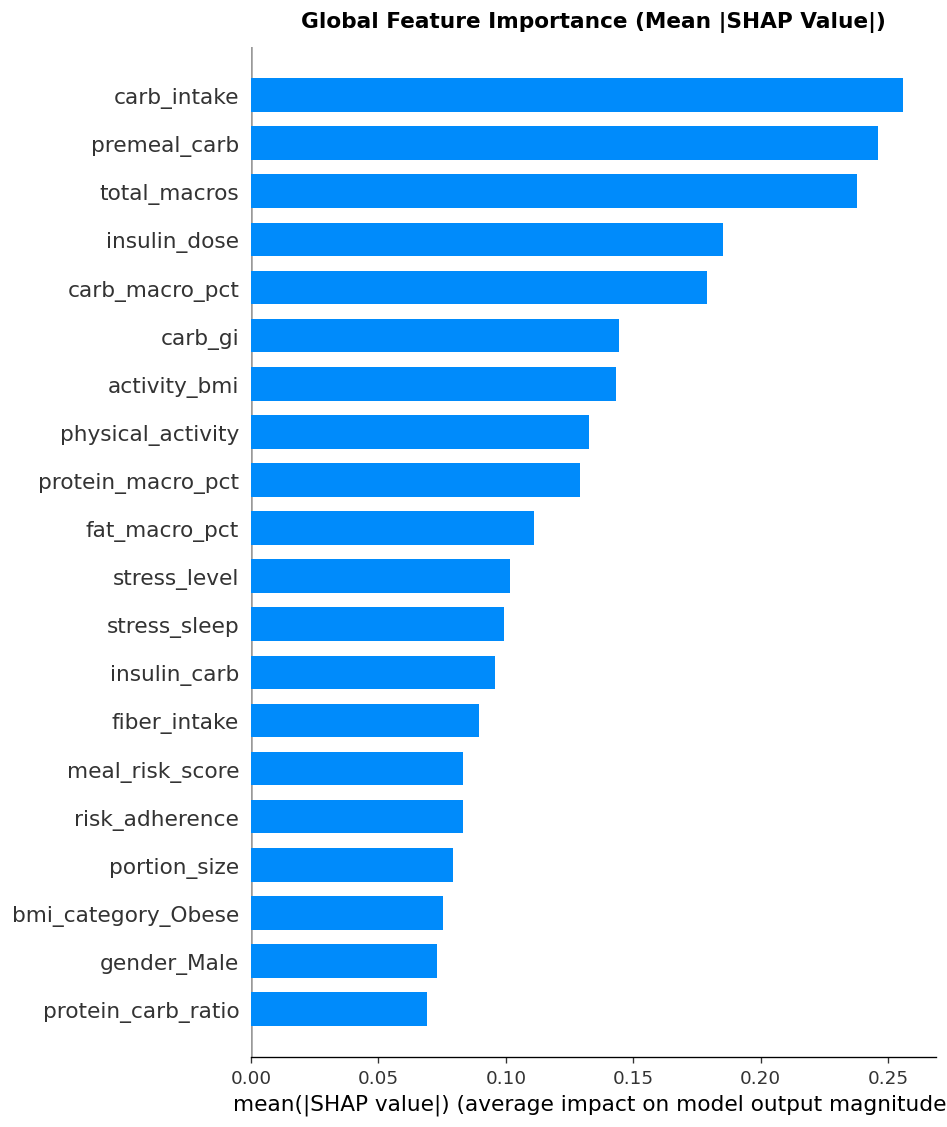

In [40]:
# mean absolute SHAP value per feature — gives overall importance ranking
shap.summary_plot(
    shap_values,
    X_test_scaled,
    plot_type="bar",
    max_display=20,
    show=False
)
plt.title("Global Feature Importance (Mean |SHAP Value|)",
          fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("shap_global_importance.png")
plt.show()

---
## 4. SHAP Beeswarm Plot - Direction & Magnitude
Shows both the importance AND the direction of each feature's impact. Red = high feature value, Blue = low feature value.

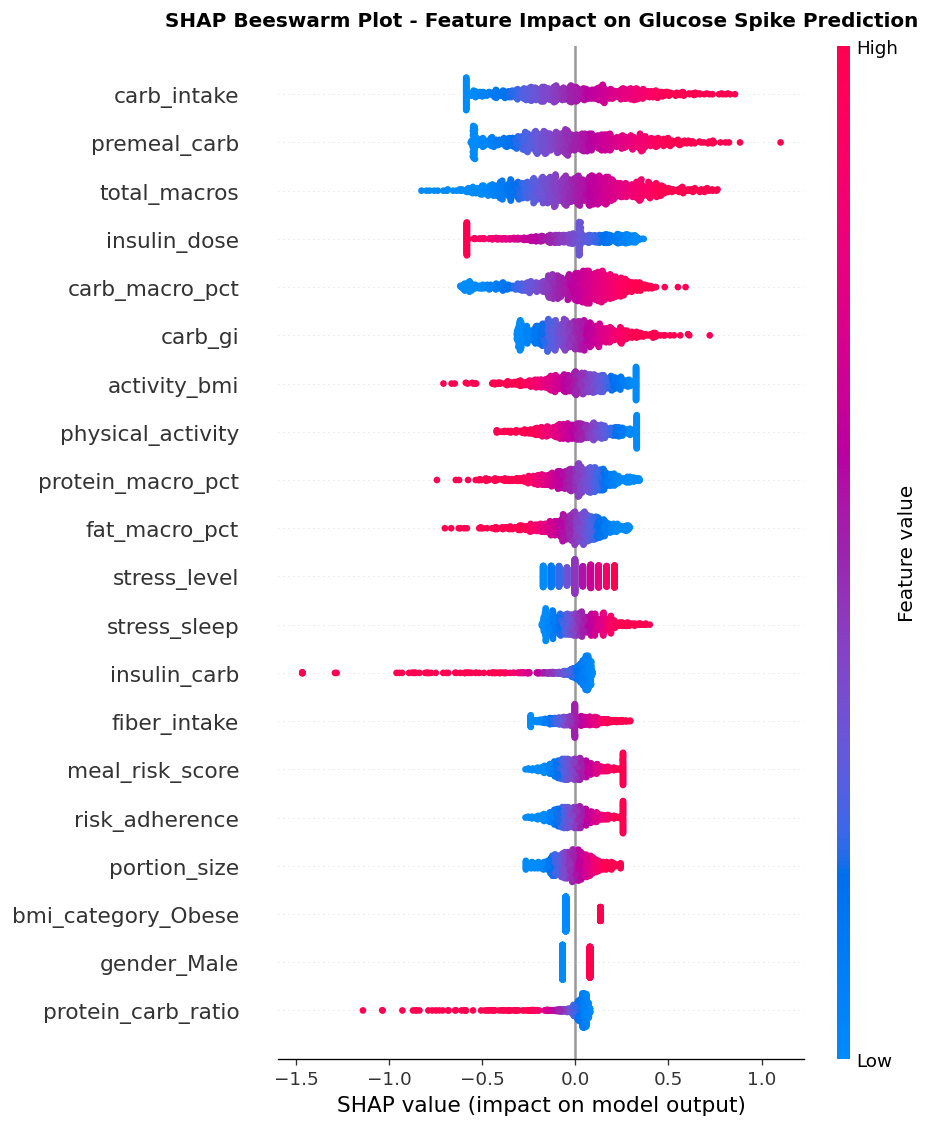

In [41]:
# beeswarm is the most informative SHAP plot — it shows:
# - which features matter most (y axis order)
# - whether high values increase or decrease spike risk (left vs right)
# - the distribution of impact across all patients (spread of dots)
shap.summary_plot(
    shap_values,
    X_test_scaled,
    max_display=20,
    show=False
)
plt.title("SHAP Beeswarm Plot - Feature Impact on Glucose Spike Prediction",
          fontsize=12, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("shap_beeswarm.png")
plt.show()

> **How to read the beeswarm plot:**
>
> - Each dot is one patient
> - **Position on x-axis** - positive SHAP value = pushes prediction towards spike, negative = pushes away
> - **Colour** - red = that patient had a HIGH value for that feature, blue = LOW value
> - **Example:** if `carb_intake` dots are red on the right → high carb intake strongly increases spike risk
> - **Example:** if `fiber_carb_ratio` dots are red on the left → high fiber ratio reduces spike risk

---
## 5. SHAP Dependence Plots - Top Features
Shows exactly how each top feature's value relates to its SHAP impact, coloured by an interacting feature.

In [42]:
# identify top 6 features by mean absolute SHAP value
mean_abs_shap = np.abs(shap_values).mean(axis=0)
top6_idx      = np.argsort(mean_abs_shap)[::-1][:6]
top6_features = [feature_cols[i] for i in top6_idx]

print("Top 6 features by SHAP importance:")
for i, feat in enumerate(top6_features, 1):
    print(f"  {i}. {feat}  (mean |SHAP| = {mean_abs_shap[top6_idx[i-1]]:.4f})")

Top 6 features by SHAP importance:
  1. carb_intake  (mean |SHAP| = 0.2559)
  2. premeal_carb  (mean |SHAP| = 0.2460)
  3. total_macros  (mean |SHAP| = 0.2376)
  4. insulin_dose  (mean |SHAP| = 0.1853)
  5. carb_macro_pct  (mean |SHAP| = 0.1788)
  6. carb_gi  (mean |SHAP| = 0.1443)


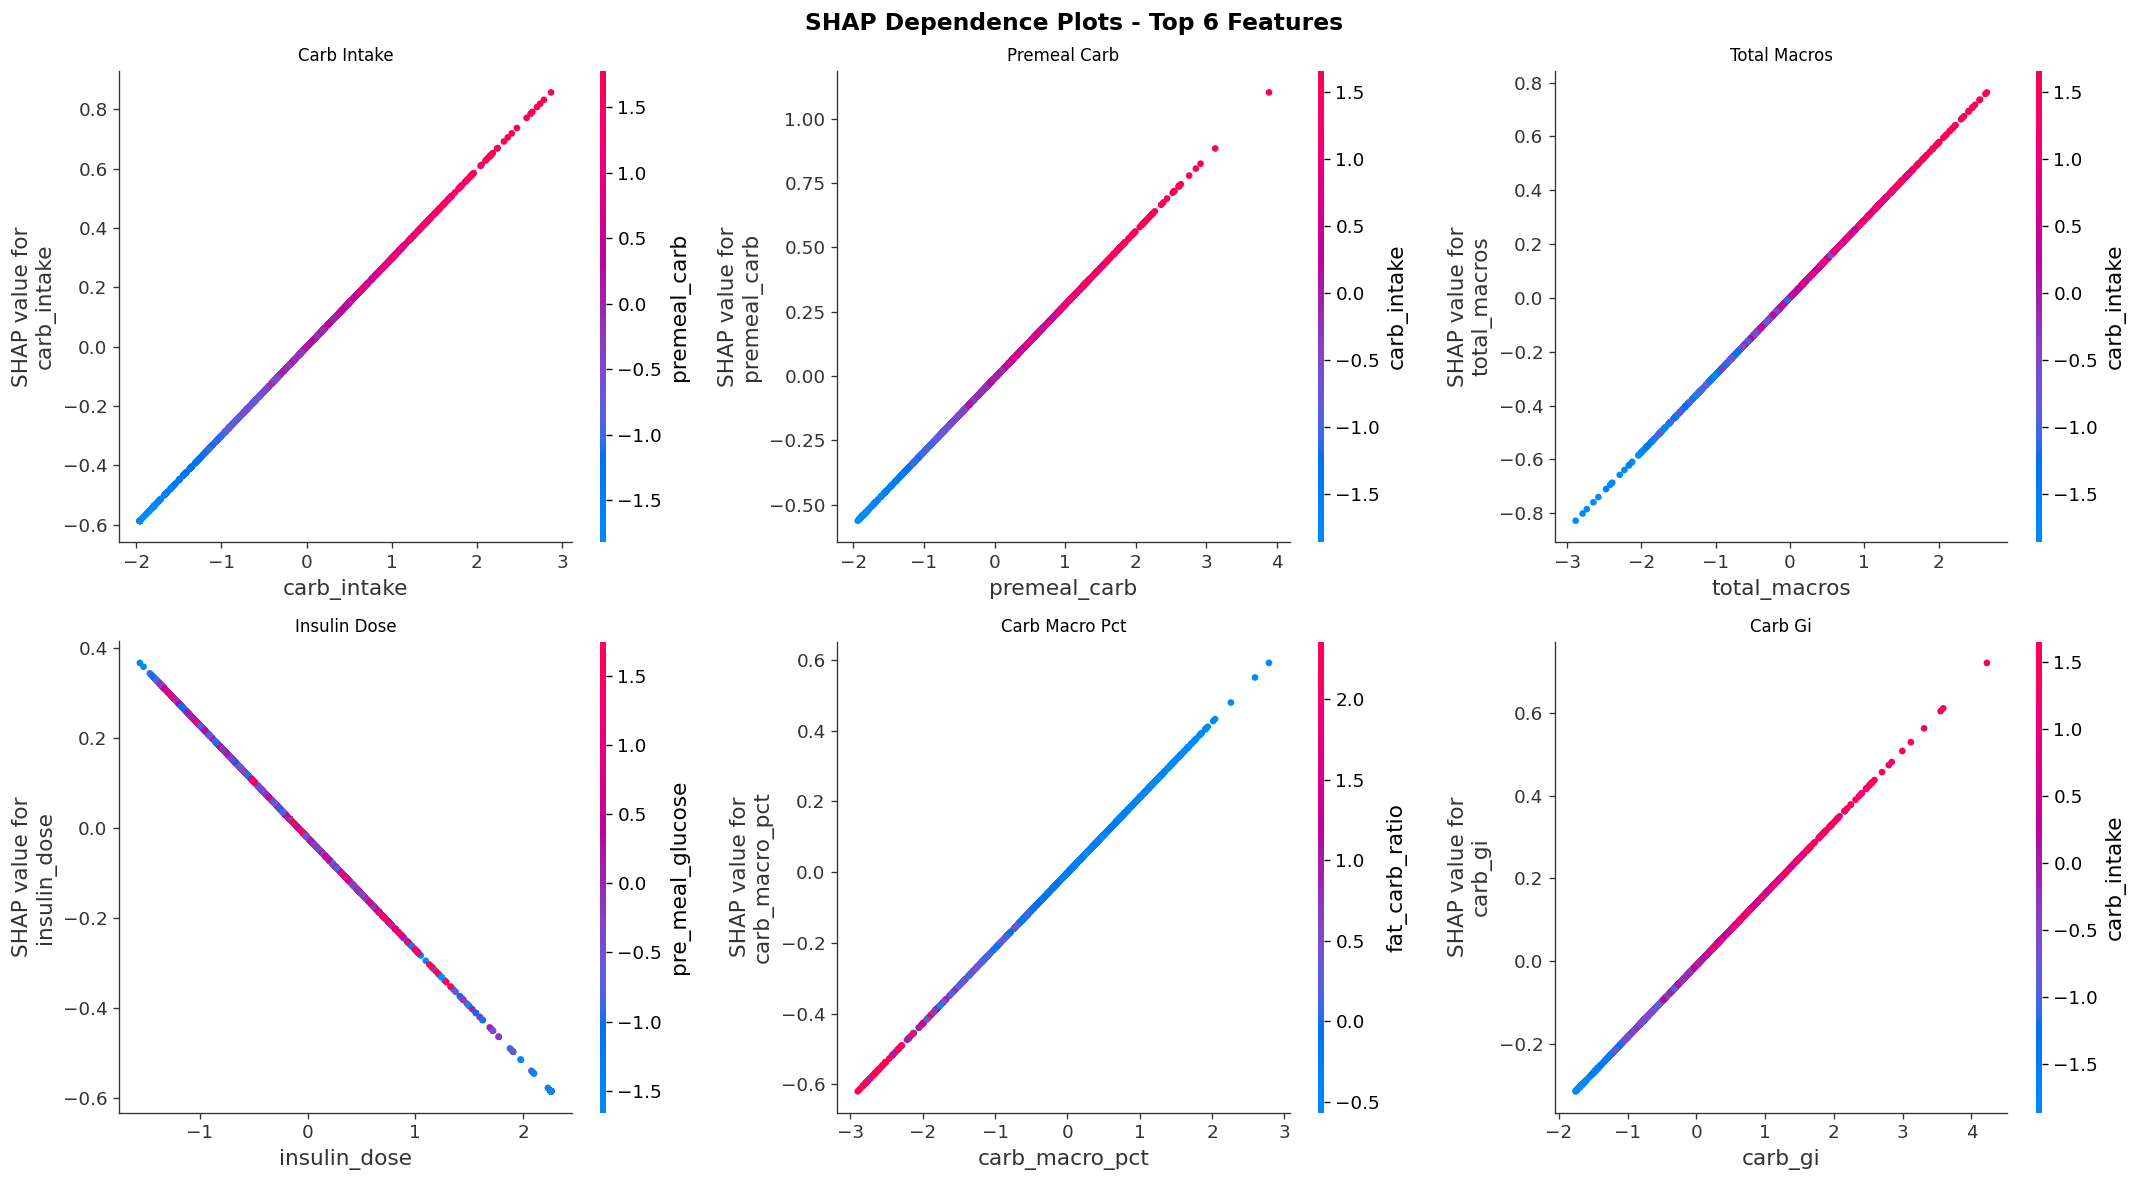

In [43]:
# dependence plots show the relationship between feature value and SHAP impact
# the colour of each dot is the automatically selected interacting feature
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("SHAP Dependence Plots - Top 6 Features",
             fontsize=14, fontweight="bold")

for ax, feat in zip(axes.flat, top6_features):
    shap.dependence_plot(
        feat,
        shap_values,
        X_test_scaled,
        ax=ax,
        show=False
    )
    ax.set_title(feat.replace("_", " ").title(), fontsize=10)

plt.tight_layout()
plt.savefig("shap_dependence_plots.png")
plt.show()

---
## 6. Individual Patient Explanations - Waterfall Plot
Explains a single prediction step by step and shows exactly which features pushed this patient's prediction up or down.

In [44]:
# waterfall plot for a patient the model predicted as HIGH RISK (spike = 1)
# find a true positive that is, a patient who actually had a spike and model predicted spike
spike_indices = np.where(
    (y_test.values == 1) &
    (best_model.predict(X_test_scaled) == 1)
)[0]

patient_idx = spike_indices[0]  # first true positive patient

print(f"Explaining patient index: {patient_idx}")
print(f"Actual label            : {int(y_test.values[patient_idx])} (Spike)")
print(f"Predicted label         : {best_model.predict(X_test_scaled)[patient_idx]} (Spike)")
pred_prob = best_model.predict_proba(X_test_scaled)[patient_idx, 1]
print(f"Predicted probability   : {pred_prob:.1%} chance of spike")

Explaining patient index: 3
Actual label            : 1 (Spike)
Predicted label         : 1 (Spike)
Predicted probability   : 72.2% chance of spike


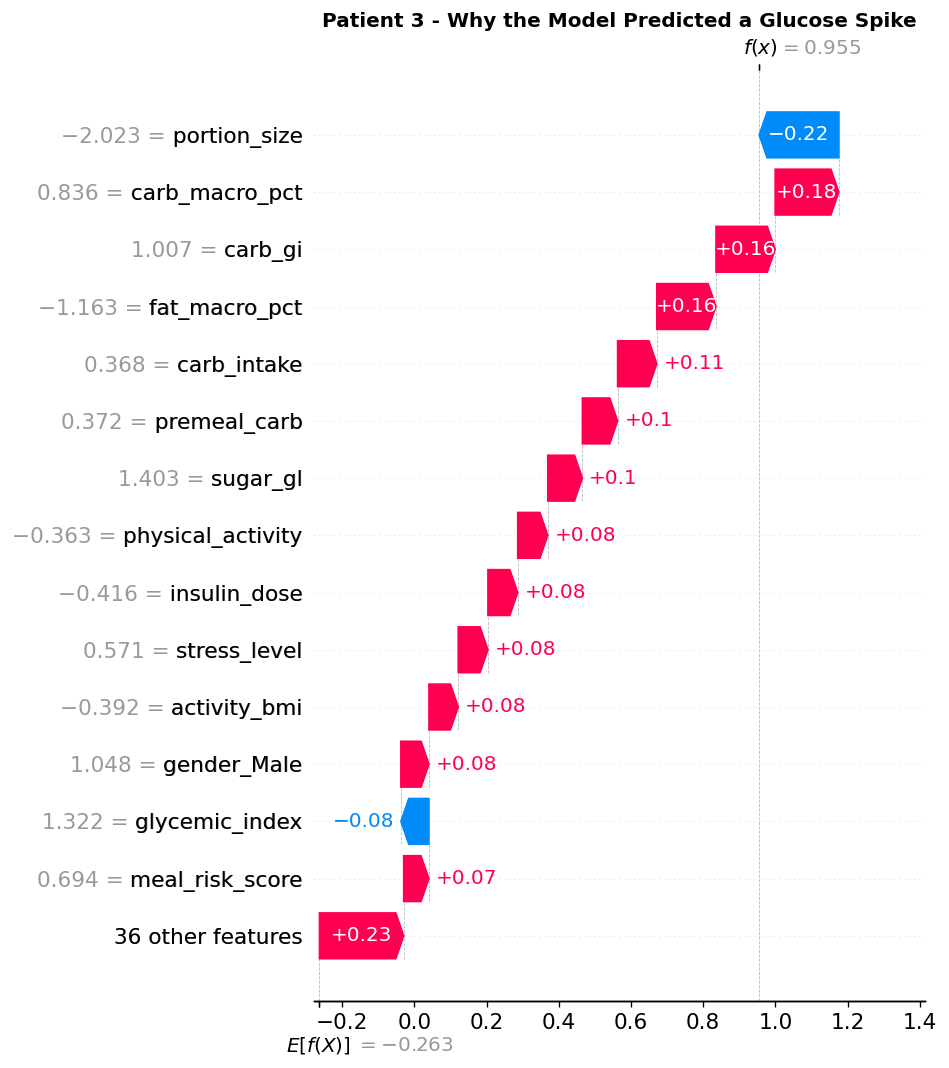

In [45]:
# waterfall plot shows the contribution of each feature to THIS patient's prediction
# starting from the baseline (average prediction) and building up to the final score
shap_exp = shap.Explanation(
    values         = shap_values[patient_idx],
    base_values    = explainer.expected_value if not isinstance(explainer.expected_value, list)
                     else explainer.expected_value[1],
    data           = X_test_scaled.iloc[patient_idx].values,
    feature_names  = feature_cols
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_exp, max_display=15, show=False)
plt.title(f"Patient {patient_idx} - Why the Model Predicted a Glucose Spike",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_waterfall_spike.png")
plt.show()

## 6.2 Waterfall Plot - Low Risk Patient (No Spike)

Explaining patient index: 0
Actual label            : 0 (No Spike)
Predicted probability   : 23.0% chance of spike


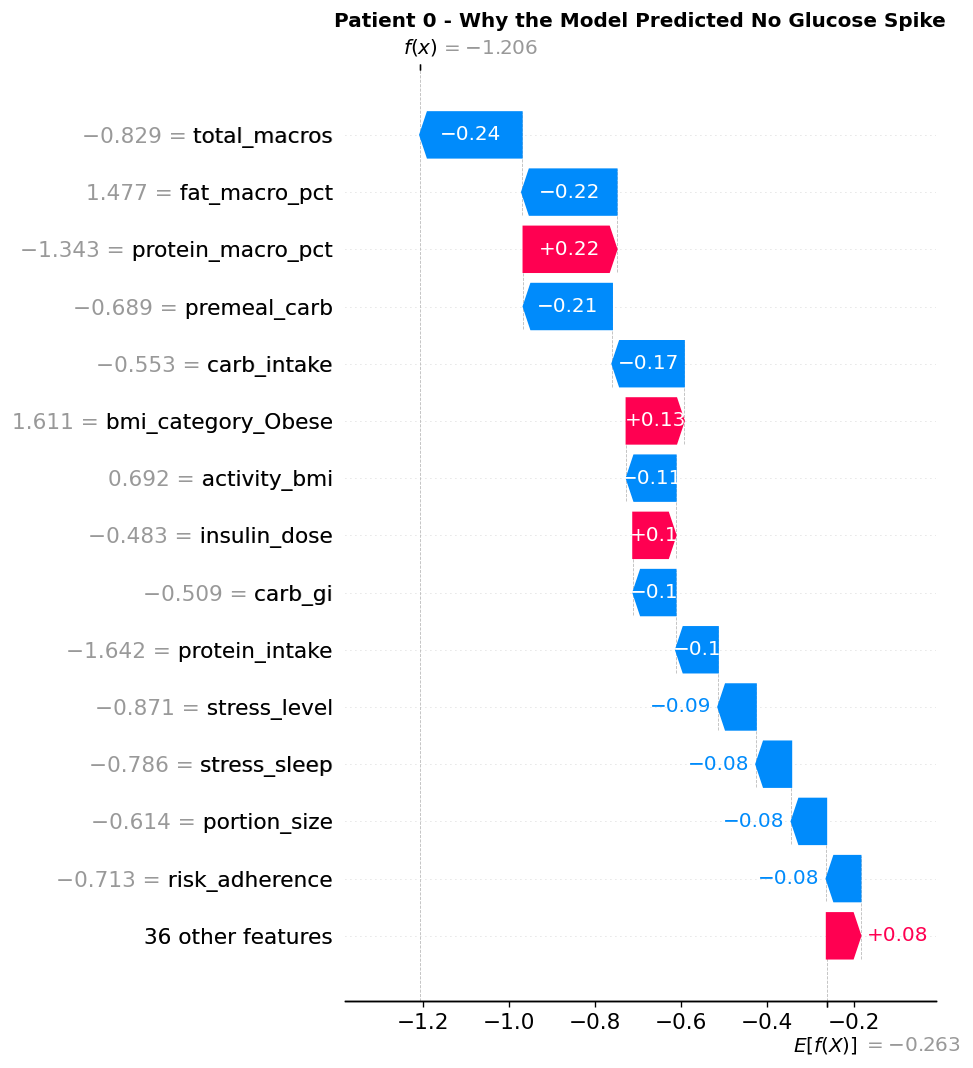

Saved: shap_waterfall_no_spike.png


In [46]:
# now explain a patient the model correctly predicted as NO spike
no_spike_indices = np.where(
    (y_test.values == 0) &
    (best_model.predict(X_test_scaled) == 0)
)[0]

patient_idx2 = no_spike_indices[0]

print(f"Explaining patient index: {patient_idx2}")
print(f"Actual label            : {int(y_test.values[patient_idx2])} (No Spike)")
pred_prob2 = best_model.predict_proba(X_test_scaled)[patient_idx2, 1]
print(f"Predicted probability   : {pred_prob2:.1%} chance of spike")

shap_exp2 = shap.Explanation(
    values        = shap_values[patient_idx2],
    base_values   = explainer.expected_value if not isinstance(explainer.expected_value, list)
                    else explainer.expected_value[1],
    data          = X_test_scaled.iloc[patient_idx2].values,
    feature_names = feature_cols
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(shap_exp2, max_display=15, show=False)
plt.title(f"Patient {patient_idx2} - Why the Model Predicted No Glucose Spike",
          fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_waterfall_no_spike.png")
plt.show()
print("Saved: shap_waterfall_no_spike.png")

---
## 7. SHAP Force Plot - Interactive Explanation

In [47]:
# force plot shows the same info as waterfall but in a horizontal format
# red bars push towards spike, blue bars push away from spike
shap.initjs()

base_val = (explainer.expected_value if not isinstance(explainer.expected_value, list)
            else explainer.expected_value[1])

force_plot = shap.force_plot(
    base_val,
    shap_values[patient_idx],
    X_test_scaled.iloc[patient_idx],
    feature_names=feature_cols
)
force_plot

---
## 8. SHAP Summary - Clinical Insights

In [48]:
# build a clean feature importance table for the project report
mean_abs_shap  = np.abs(shap_values).mean(axis=0)
mean_shap      = shap_values.mean(axis=0)

shap_summary = pd.DataFrame({
    "Feature"           : feature_cols,
    "Mean |SHAP|"       : mean_abs_shap,
    "Mean SHAP"         : mean_shap,
    "Direction"         : ["Increases Risk" if v > 0 else "Decreases Risk" for v in mean_shap]
}).sort_values("Mean |SHAP|", ascending=False).reset_index(drop=True)

print("Top 15 Most Influential Features:")
print(shap_summary.head(15).to_string(index=False))

# save the summary table
shap_summary.to_csv("shap_feature_importance.csv", index=False)
print("\nSaved: shap_feature_importance.csv")

Top 15 Most Influential Features:
          Feature  Mean |SHAP|  Mean SHAP      Direction
      carb_intake     0.255945  -0.007375 Decreases Risk
     premeal_carb     0.245989  -0.009126 Decreases Risk
     total_macros     0.237576  -0.006222 Decreases Risk
     insulin_dose     0.185317  -0.009957 Decreases Risk
   carb_macro_pct     0.178781  -0.007946 Decreases Risk
          carb_gi     0.144256  -0.011282 Decreases Risk
     activity_bmi     0.143074   0.013588 Increases Risk
physical_activity     0.132522   0.026479 Increases Risk
protein_macro_pct     0.129006  -0.001410 Decreases Risk
    fat_macro_pct     0.111047  -0.006848 Decreases Risk
     stress_level     0.101790   0.019504 Increases Risk
     stress_sleep     0.099261   0.015947 Increases Risk
     insulin_carb     0.095746  -0.021380 Decreases Risk
     fiber_intake     0.089478  -0.002546 Decreases Risk
   risk_adherence     0.083042  -0.004221 Decreases Risk

Saved: shap_feature_importance.csv


---
## Summary

| Plot | What it Shows |
|---|---|
| **Bar Plot** | Overall importance ranking. Which features matter most across all patients |
| **Beeswarm** | Importance + direction + distribution. The most complete global view |
| **Dependence Plots** | How each top feature's value relates to its spike risk contribution |
| **Waterfall (Spike)** | Step-by-step explanation of why a specific high-risk patient was flagged |
| **Waterfall (No Spike)** | Step-by-step explanation of why a low-risk patient was cleared |
| **Force Plot** | Same as waterfall in horizontal interactive format |

> **Key clinical takeaway:** The SHAP analysis confirms that the dietary features engineered in notebook 03, particularly `carb_intake`, `sugar_carb_ratio`, `premeal_carb`, and `gi_portion` are the dominant drivers of glucose spike prediction. Lifestyle features (`lifestyle_risk_score`, `insulin_carb`) contribute meaningfully as secondary risk factors. This validates the clinical relevance of the feature engineering pipeline and provides actionable insight for dietary intervention.